# 02 — K-Means Clustering Model

**Nguồn dữ liệu**: MySQL → bảng `cleaned_cars`

**Mục tiêu**:
1. Lấy dữ liệu sạch từ DB
2. Scale features bằng `RobustScaler`
3. Xác định K tối ưu (Elbow Method + Silhouette Score)
4. Train K-Means và phân tích từng cluster
5. Lưu nhãn cluster ngược về DB (cột `cluster_label`)

> ⚠️ **Yêu cầu**: Đã chạy `python -m src.etl_pipeline` trước.

## 0. Import & Cấu hình

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Thư mục lưu hình ảnh output
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

from src.db_connector import DBConnector
from src.business_insights import (
    standardize_car_columns, compute_market_gap, plot_market_gap,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

RANDOM_STATE = 42
print(f'✓ Import thành công')
print(f'✓ Output dir: {OUTPUT_DIR}')

✓ Import thành công
✓ Output dir: /Users/macbook/Documents/Car_Data_Analysis/output


## 1. Load dữ liệu từ MySQL

In [2]:
# Ưu tiên đọc từ MySQL; nếu môi trường chưa mở DB thì dùng CSV backup đã clean.
db = None
conn = None
try:
    db = DBConnector()
    conn = db.get_connection()
    df = pd.read_sql("""
        SELECT 
            id, ten_xe, gia, nam_sx, km_da_di,
            so_ghe, nhien_lieu, kieu_dang, tinh_trang,
            hop_so, xuat_xu, log_gia, log_km
        FROM cleaned_cars
        ORDER BY id
    """, conn)
    data_source = 'MySQL: cleaned_cars'
except Exception as exc:
    print(f'Không kết nối được MySQL, chuyển sang CSV backup: {exc}')
    csv_path = ROOT / 'data' / 'processed' / 'car_data_cleaned.csv'
    df = pd.read_csv(csv_path)
    data_source = f'CSV backup: {csv_path.name}'

df = standardize_car_columns(df)

print(f'Nguồn dữ liệu: {data_source}')
print(f'Dữ liệu: {df.shape[0]:,} records, {df.shape[1]} cột')
df.head()

[DB] Kết nối thành công → MySQL Server 9.1.0 | DB: car_analytics
Nguồn dữ liệu: MySQL: cleaned_cars
Dữ liệu: 2,958 records, 19 cột


,id,ten_xe,gia,nam_sx,km_da_di,so_ghe,nhien_lieu,kieu_dang,tinh_trang,hop_so,xuat_xu,log_gia,log_km,brand,model_line,brand_group,age,gia_trieu,price_band
0,1,Hyundai Kona 2.0 AT Đặc biệt 2019,450000000,2019,80000.0,5,Máy xăng,SUV,Xe cũ,Số tự động,Trong nước,19.9248,11.28980,Hyundai,Hyundai Kona,Hàn,6,450.0,300-500tr
1,2,Ford Everest Titanium 2.0 AT 4x2 2023,1225000000,2023,22000.0,7,Máy dầu,SUV,Xe cũ,Số tự động,Nhập khẩu,20.9262,9.99884,Ford,Ford Everest,Mỹ,2,1225.0,1-1.5ty
2,3,Ford Transit 2022,715000000,2022,40000.0,16,Máy dầu,Van/Minivan,Xe cũ,Số sàn,Trong nước,20.3878,10.59670,Ford,Ford Transit,Mỹ,3,715.0,700tr-1ty
3,4,Mazda 3 Sedan 1.5L Luxury 2020,499000000,2020,3200.0,5,Máy xăng,Sedan,Xe cũ,Số tự động,Trong nước,20.0281,8.07122,Mazda,Mazda 3,Nhật,5,499.0,300-500tr
4,5,Mitsubishi Xpander 1.5 MT 2019,420000000,2019,76000.0,7,Máy xăng,MPV,Xe cũ,Số tự động,Nhập khẩu,19.8558,11.23850,Mitsubishi,Mitsubishi Xpander,Nhật,6,420.0,300-500tr


## 2. Chuẩn bị Features cho Clustering

In [3]:
# Features dùng để clustering
FEATURES = ['log_gia', 'log_km', 'nam_sx']

X = df[FEATURES].dropna()
valid_idx = X.index  # Giữ lại index gốc để map lại sau

# Scale bằng RobustScaler (ít nhạy cảm với outlier hơn StandardScaler)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features: {FEATURES}')
print(f'Shape sau scaling: {X_scaled.shape}')
print(f'\nThống kê sau RobustScaler:')
pd.DataFrame(X_scaled, columns=FEATURES).describe().round(3)

Features: ['log_gia', 'log_km', 'nam_sx']
Shape sau scaling: (2958, 3)

Thống kê sau RobustScaler:


,log_gia,log_km,nam_sx
count,2958.000,2958.000,2958.000
mean,0.148,0.478,-0.456
std,0.966,0.492,0.890
min,-3.664,0.000,-4.600
25%,-0.427,0.000,-0.800
50%,0.000,0.000,0.000
75%,0.573,1.000,0.200
max,4.150,1.253,0.200


## 3. Tìm K tối ưu — Elbow Method

In [4]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f'K={k}: Inertia={kmeans.inertia_:,.0f} | Silhouette={sil:.4f}')

print(f'\n→ K tối ưu theo Silhouette: K={k_range.start + np.argmax(sil_scores)}')

K=2: Inertia=3,273 | Silhouette=0.4444


K=3: Inertia=2,017 | Silhouette=0.4489


K=4: Inertia=1,433 | Silhouette=0.4618
K=5: Inertia=1,200 | Silhouette=0.4481


K=6: Inertia=1,014 | Silhouette=0.4186


K=7: Inertia=853 | Silhouette=0.4285


K=8: Inertia=739 | Silhouette=0.4163


K=9: Inertia=658 | Silhouette=0.4087


K=10: Inertia=588 | Silhouette=0.4151

→ K tối ưu theo Silhouette: K=4


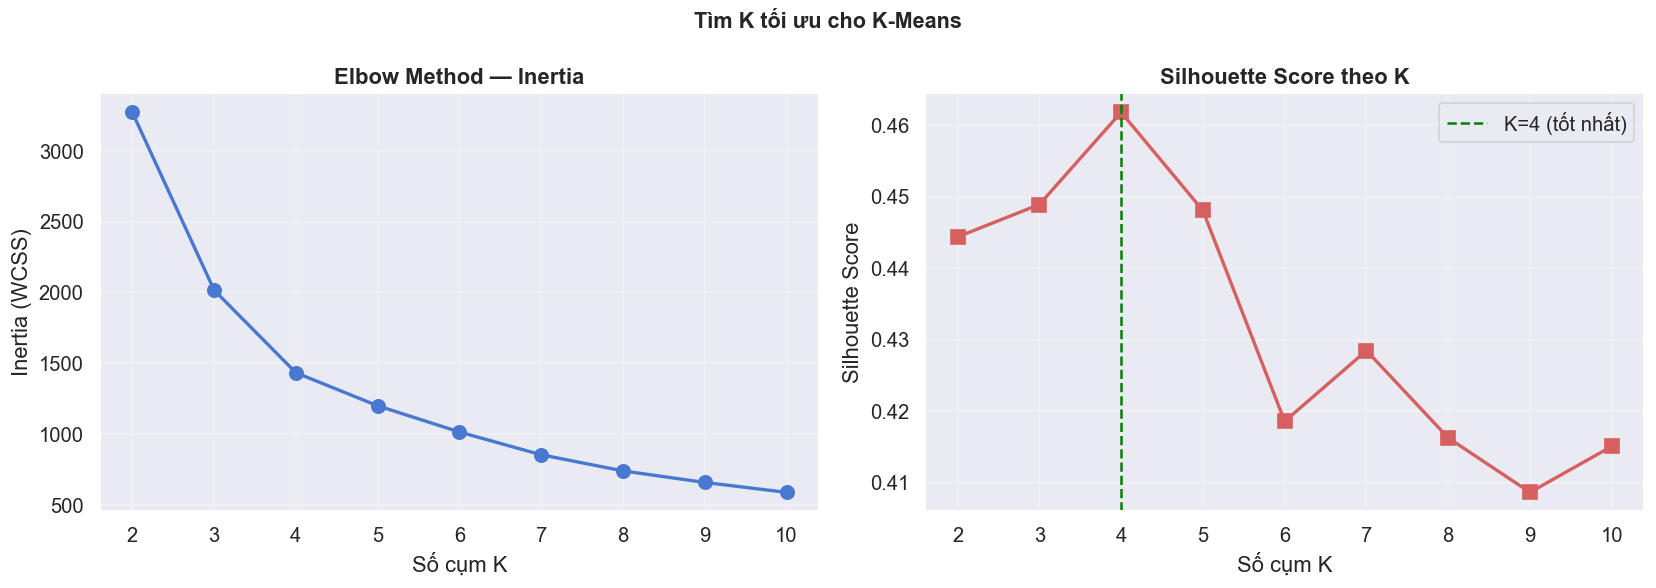

✓ Đã lưu → output/kmeans_01_elbow_silhouette.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia', fontweight='bold')
axes[0].set_xlabel('Số cụm K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, alpha=0.3)

# Silhouette curve
axes[1].plot(list(k_range), sil_scores, 'rs-', linewidth=2, markersize=8)
best_k_idx = np.argmax(sil_scores)
axes[1].axvline(x=list(k_range)[best_k_idx], color='green', linestyle='--',
                label=f'K={list(k_range)[best_k_idx]} (tốt nhất)')
axes[1].set_title('Silhouette Score theo K', fontweight='bold')
axes[1].set_xlabel('Số cụm K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Tìm K tối ưu cho K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_01_elbow_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/kmeans_01_elbow_silhouette.png')

## 4. Train K-Means với K tối ưu

In [6]:
# Chọn K — thay đổi nếu muốn
K_OPTIMAL = 4

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Gắn nhãn cluster vào DataFrame gốc
df_result = df.loc[valid_idx].copy()
df_result['cluster'] = cluster_labels

print(f'K = {K_OPTIMAL}')
print(f'Silhouette Score cuối: {silhouette_score(X_scaled, cluster_labels):.4f}')
print(f'\nSố lượng mỗi cụm:')
print(df_result['cluster'].value_counts().sort_index())

K = 4
Silhouette Score cuối: 0.4618

Số lượng mỗi cụm:
cluster
0     555
1     400
2    1145
3     858
Name: count, dtype: int64


## 5. Phân tích đặc trưng từng Cluster

In [7]:
# Thống kê trung bình của từng cụm
cluster_stats = df_result.groupby('cluster').agg(
    so_luong=('id', 'count'),
    gia_tb=('gia', 'mean'),
    gia_min=('gia', 'min'),
    gia_max=('gia', 'max'),
    km_tb=('km_da_di', 'mean'),
    nam_sx_tb=('nam_sx', 'mean'),
).round(0)

# Chuyển giá sang tỷ VND
for col in ['gia_tb', 'gia_min', 'gia_max']:
    cluster_stats[col] = (cluster_stats[col] / 1e9).round(2)

cluster_stats.columns = ['Số lượng', 'Giá TB (tỷ)', 'Giá Min (tỷ)', 'Giá Max (tỷ)', 'Km TB', 'Năm SX TB']
print('=== Thống kê từng Cluster ===')
cluster_stats

=== Thống kê từng Cluster ===


,Số lượng,Giá TB (tỷ),Giá Min (tỷ),Giá Max (tỷ),Km TB,Năm SX TB
cluster,,,,,,
0,555,3.70,1.33,26.79,8545.0,2024.0
1,400,0.30,0.04,1.48,116172.0,2013.0
2,1145,0.67,0.02,1.40,180.0,2025.0
3,858,0.71,0.18,2.45,62419.0,2020.0


## 6. Visualize Clusters

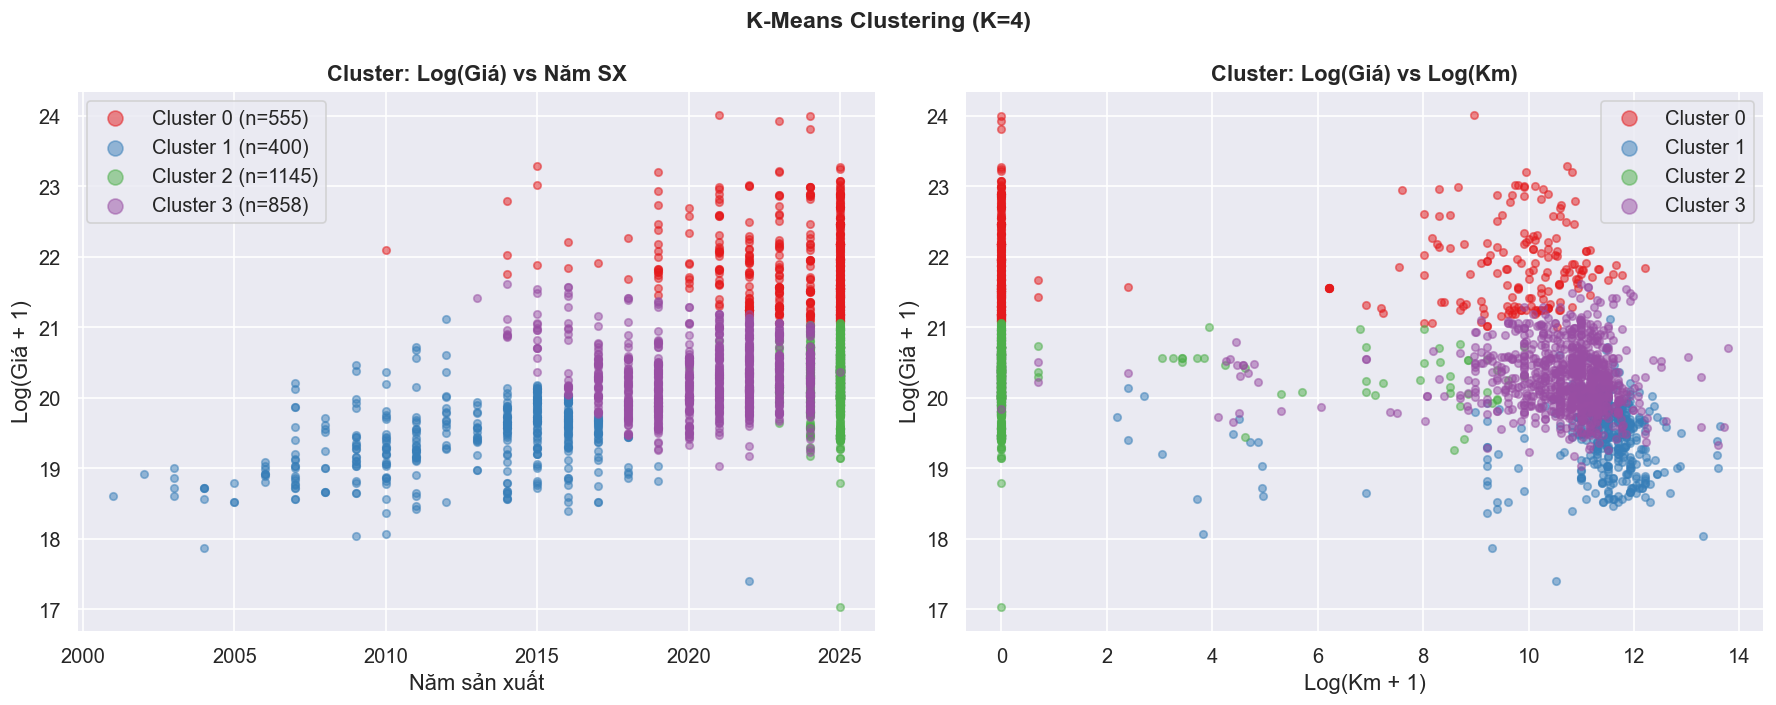

✓ Đã lưu → output/kmeans_02_scatter_clusters.png


In [8]:
palette = sns.color_palette('Set1', K_OPTIMAL)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: Log(Giá) vs Năm SX
for k in range(K_OPTIMAL):
    mask = df_result['cluster'] == k
    axes[0].scatter(
        df_result.loc[mask, 'nam_sx'],
        df_result.loc[mask, 'log_gia'],
        label=f'Cluster {k} (n={mask.sum()})',
        alpha=0.5, s=20, color=palette[k]
    )

axes[0].set_title('Cluster: Log(Giá) vs Năm SX', fontweight='bold')
axes[0].set_xlabel('Năm sản xuất')
axes[0].set_ylabel('Log(Giá + 1)')
axes[0].legend(markerscale=2)

# Scatter: Log(Giá) vs Log(Km)
for k in range(K_OPTIMAL):
    mask = df_result['cluster'] == k
    axes[1].scatter(
        df_result.loc[mask, 'log_km'],
        df_result.loc[mask, 'log_gia'],
        label=f'Cluster {k}',
        alpha=0.5, s=20, color=palette[k]
    )

axes[1].set_title('Cluster: Log(Giá) vs Log(Km)', fontweight='bold')
axes[1].set_xlabel('Log(Km + 1)')
axes[1].set_ylabel('Log(Giá + 1)')
axes[1].legend(markerscale=2)

plt.suptitle(f'K-Means Clustering (K={K_OPTIMAL})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_02_scatter_clusters.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/kmeans_02_scatter_clusters.png')

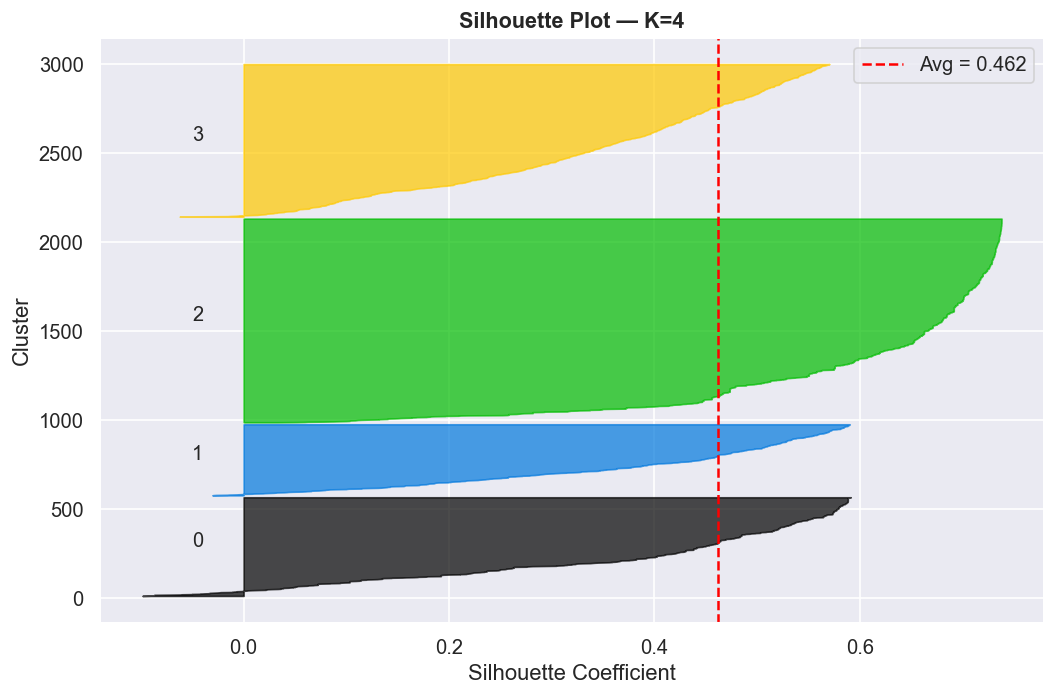

✓ Đã lưu → output/kmeans_03_silhouette_plot.png


In [9]:
# Silhouette Plot chi tiết
sil_vals = silhouette_samples(X_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10

for k in range(K_OPTIMAL):
    kth_sil = np.sort(sil_vals[cluster_labels == k])
    size_k = kth_sil.shape[0]
    y_upper = y_lower + size_k

    color = cm.nipy_spectral(float(k) / K_OPTIMAL)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, kth_sil, facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_k, str(k), fontsize=12)
    y_lower = y_upper + 10

avg_sil = silhouette_score(X_scaled, cluster_labels)
ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Avg = {avg_sil:.3f}')
ax.set_title(f'Silhouette Plot — K={K_OPTIMAL}', fontweight='bold', fontsize=13)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_03_silhouette_plot.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/kmeans_03_silhouette_plot.png')

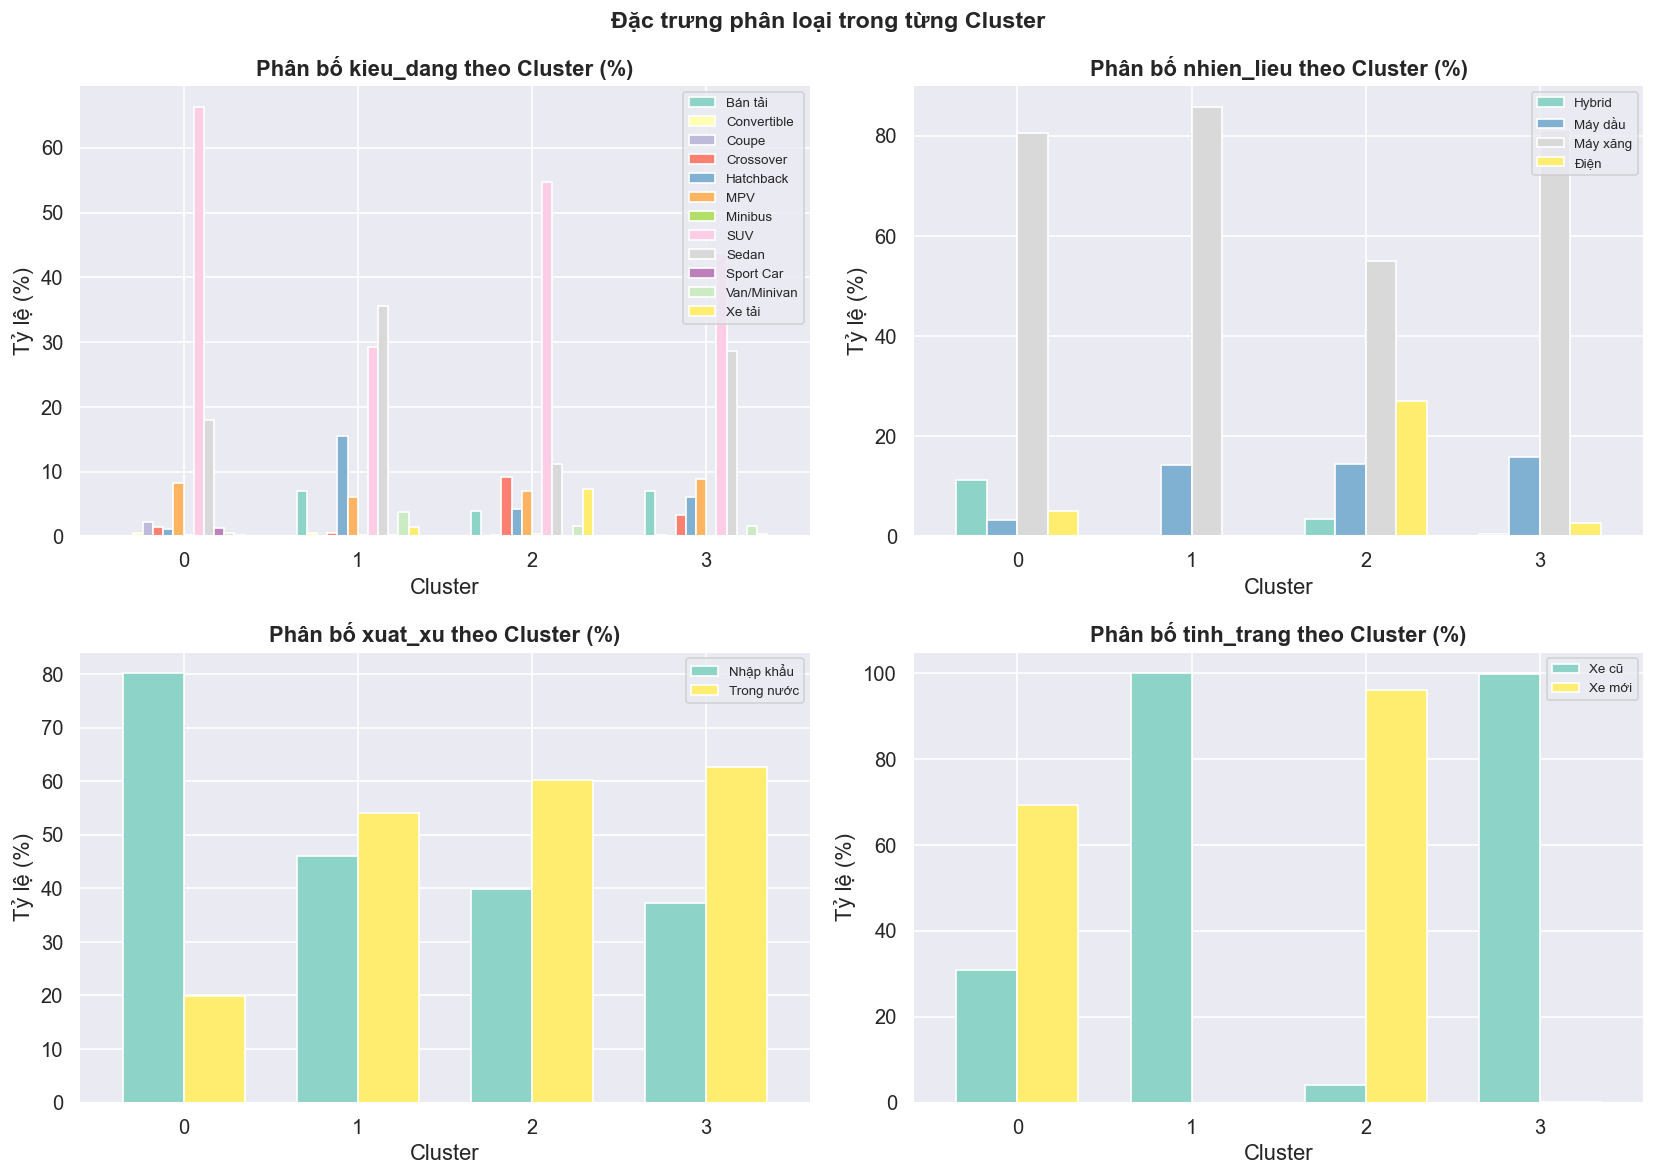

✓ Đã lưu → output/kmeans_04_cluster_categories.png


In [10]:
# Phân bố đặc trưng phân loại trong từng cluster
cat_cols = ['kieu_dang', 'nhien_lieu', 'xuat_xu', 'tinh_trang']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df_result['cluster'], df_result[col], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set3', edgecolor='white', width=0.7)
    axes[i].set_title(f'Phân bố {col} theo Cluster (%)', fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Tỷ lệ (%)')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(loc='upper right', fontsize=8)

plt.suptitle('Đặc trưng phân loại trong từng Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_04_cluster_categories.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Đã lưu → output/kmeans_04_cluster_categories.png')

## 7. Business Insight: Market Gap & Supply Concentration

Mục tiêu kinh doanh: dùng cluster và tầm giá/kiểu dáng để phát hiện phân khúc đang quá đông nguồn cung và phân khúc còn khan hàng tương đối.

=== Hồ sơ cung theo cluster ===


,business_cluster,n,median_price_million,mean_price_million,median_km,median_year,median_seats,dominant_style,new_share_pct,share_pct,persona
2,2,1145,640.0,665.0,0.0,2025.0,5.0,SUV,96.0,38.7,Xe mới/phổ thông
3,3,858,602.0,705.0,55066.0,2021.0,5.0,SUV,0.1,29.0,Xe cũ tầm trung
0,0,555,2629.0,3698.0,0.0,2025.0,5.0,SUV,69.2,18.8,Xe mới/premium cao cấp
1,1,400,292.0,305.0,100000.0,2014.0,5.0,Sedan,0.0,13.5,Xe cũ giá rẻ


=== Top phân khúc đông nguồn cung nhất ===


,kieu_dang,price_band,n,median_price_million,median_year,median_km,share_pct
42,SUV,700tr-1ty,398,835.0,2025.0,0.0,13.5
41,SUV,500-700tr,305,604.0,2025.0,0.0,10.3
47,Sedan,300-500tr,226,410.0,2021.0,49500.0,7.6
40,SUV,300-500tr,194,450.0,2020.5,38500.0,6.6
45,SUV,>3ty,185,4430.0,2025.0,0.0,6.3
44,SUV,1.5-3ty,184,2148.0,2025.0,0.0,6.2
43,SUV,1-1.5ty,155,1199.0,2024.0,0.0,5.2
46,Sedan,<300tr,98,229.0,2014.0,100000.0,3.3
20,Hatchback,<300tr,92,236.0,2016.0,68500.0,3.1
48,Sedan,500-700tr,92,559.0,2022.0,31500.0,3.1


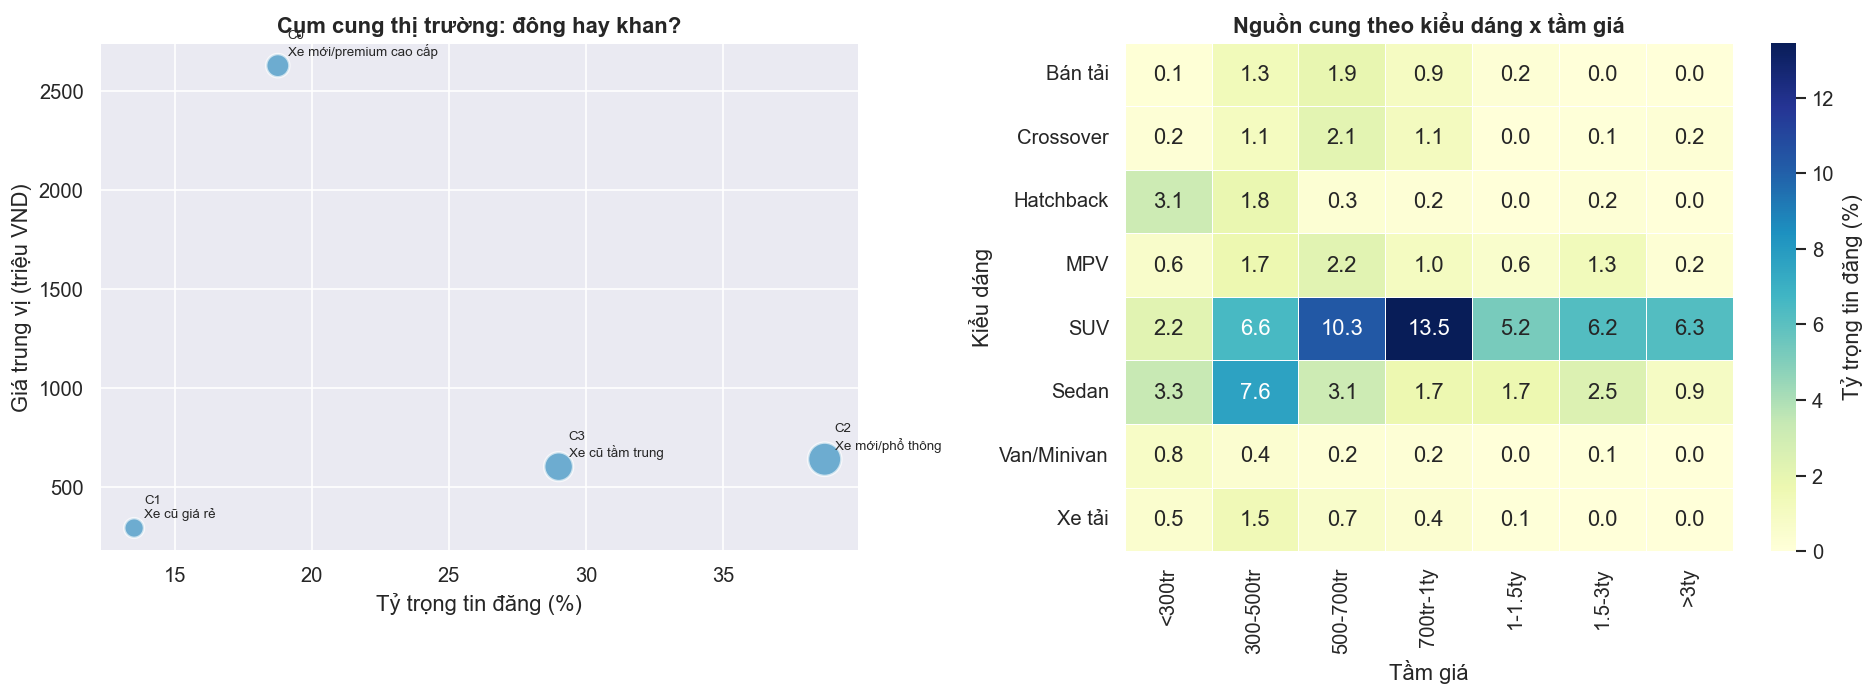

Insight: cluster C2 (Xe mới/phổ thông) đang chiếm 38.7% tổng nguồn cung, giá trung vị ~640 triệu. Đây là vùng dễ cạnh tranh giá nhất.
Phân khúc dày nhất hiện là SUV 700tr-1ty (13.5% tin đăng). Không nên tăng tồn kho phân khúc này nếu không có lợi thế tốc độ bán.
Các vùng nguồn cung thấp hơn nhưng giá trị còn đáng theo dõi:


,kieu_dang,price_band,n,share_pct,median_price_million
52,Sedan,>3ty,27,0.9,4150.0
51,Sedan,1.5-3ty,73,2.5,2035.0
31,MPV,1.5-3ty,38,1.3,1799.5
30,MPV,1-1.5ty,17,0.6,1279.0
50,Sedan,1-1.5ty,50,1.7,1274.5


✓ Đã lưu → output/business_04_market_gap_supply.png


In [11]:
market_df, cluster_business, segment_business = compute_market_gap(
    df_result,
    cluster_col='cluster',
)

print('=== Hồ sơ cung theo cluster ===')
display(cluster_business.round({
    'median_price_million': 0,
    'mean_price_million': 0,
    'median_km': 0,
    'share_pct': 1,
    'new_share_pct': 1,
}))

print('=== Top phân khúc đông nguồn cung nhất ===')
display(segment_business.head(12).round({
    'median_price_million': 0,
    'median_km': 0,
    'share_pct': 1,
}))

plot_market_gap(
    market_df,
    cluster_business,
    segment_business,
    OUTPUT_DIR / 'business_04_market_gap_supply.png',
)

top_cluster = cluster_business.iloc[0]
top_segment = segment_business.iloc[0]
low_supply = segment_business[(segment_business['n'] >= 10) & (segment_business['share_pct'] < 2.5)]
low_supply = low_supply.sort_values(['median_price_million', 'n'], ascending=[False, False]).head(5)

print(
    f"Insight: cluster C{int(top_cluster['business_cluster'])} ({top_cluster['persona']}) "
    f"đang chiếm {top_cluster['share_pct']:.1f}% tổng nguồn cung, giá trung vị "
    f"~{top_cluster['median_price_million']:.0f} triệu. Đây là vùng dễ cạnh tranh giá nhất."
)
print(
    f"Phân khúc dày nhất hiện là {top_segment['kieu_dang']} {top_segment['price_band']} "
    f"({top_segment['share_pct']:.1f}% tin đăng). Không nên tăng tồn kho phân khúc này nếu không có lợi thế tốc độ bán."
)
if not low_supply.empty:
    print('Các vùng nguồn cung thấp hơn nhưng giá trị còn đáng theo dõi:')
    display(low_supply[['kieu_dang', 'price_band', 'n', 'share_pct', 'median_price_million']].round(1))
print('✓ Đã lưu → output/business_04_market_gap_supply.png')

## 8. Lưu nhãn Cluster về MySQL

In [12]:
if db is not None:
    # Cập nhật cluster_label vào bảng cleaned_cars
    ids = df_result['id'].tolist()
    labels = df_result['cluster'].tolist()

    db.update_cluster_labels(ids, labels)
    print(f'✓ Đã cập nhật cluster_label cho {len(ids):,} records trong DB')

    # Xác nhận
    check = pd.read_sql("""
        SELECT cluster_label, COUNT(*) as so_luong
        FROM cleaned_cars
        GROUP BY cluster_label
        ORDER BY cluster_label
    """, conn)
    print('\nKiểm tra phân phối cluster trong DB:')
    display(check)
else:
    print('✓ Notebook chạy bằng CSV backup, bỏ qua bước cập nhật cluster_label vào MySQL')

[DB] Đã cập nhật cluster_label cho 0 dòng.
✓ Đã cập nhật cluster_label cho 2,958 records trong DB

Kiểm tra phân phối cluster trong DB:


,cluster_label,so_luong
0,0,555
1,1,400
2,2,1145
3,3,858


## 9. Đóng kết nối

In [13]:
if db is not None:
    db.close()
    print('✓ Đã đóng kết nối DB')
else:
    print('✓ Notebook chạy bằng CSV backup, không có kết nối DB cần đóng')
print(f'\n=== TÓM TẮT ===')
print(f'K tối ưu: {K_OPTIMAL}')
print(f'Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}')
print(f'Phân bố cluster:')
for k, cnt in df_result['cluster'].value_counts().sort_index().items():
    print(f'  Cluster {k}: {cnt:,} xe')
print(f'\nTất cả biểu đồ đã lưu tại: {OUTPUT_DIR}')

[DB] Đã đóng kết nối MySQL.
✓ Đã đóng kết nối DB

=== TÓM TẮT ===
K tối ưu: 4


Silhouette Score: 0.4618
Phân bố cluster:
  Cluster 0: 555 xe
  Cluster 1: 400 xe
  Cluster 2: 1,145 xe
  Cluster 3: 858 xe

Tất cả biểu đồ đã lưu tại: /Users/macbook/Documents/Car_Data_Analysis/output
